<a href="https://colab.research.google.com/github/SrilathaWeb/Data-Science-Cohort-20/blob/main/Project-5/DBpedia_NLP_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DBpedia People Similarity & Wikipedia Sentiment Analysis
### Parts 1, 2, and 3

**Overview:**
- **Part 1** – Load DBpedia dataset, embed text with TF-IDF, find 10 nearest neighbors for a reference person
- **Part 2** – Fetch full Wikipedia pages, sentiment analysis, re-rank neighbors by Wikipedia similarity, compare rankings
- **Part 3** – Interactive widget: enter any name → display 10 closest people

## 🔧 Install & Import Dependencies

In [20]:
!pip install wikipedia-api vaderSentiment --quiet

In [42]:
import pandas as pd
import numpy as np
import requests
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from urllib.parse import unquote

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Wikipedia API
import wikipediaapi

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## 📂 Load the DBpedia Dataset

Upload your CSV file (columns: `URI`, `name`, `text`) using the cell below, or mount Google Drive.

In [43]:
# Load the uploaded file
filename = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv"
df = pd.read_csv(filename)

# Ensure expected columns exist
df.columns = df.columns.str.strip()
assert 'name' in df.columns and 'text' in df.columns, "CSV must have 'name' and 'text' columns"

# Clean data
df['name'] = df['name'].astype(str).str.strip()
df['name'] = df['name'].apply(unquote)
df['text'] = df['text'].astype(str).str.strip()
df = df.dropna(subset=['name', 'text']).reset_index(drop=True)

print(f"Loaded {len(df):,} records")
df.head()

Loaded 42,786 records


,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...


---
## PART 1 – TF-IDF Nearest Neighbors from DBpedia Text

### 1a. Build TF-IDF Matrix

In [44]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2
)

tfidf_matrix = vectorizer.fit_transform(df['text'])
print(f" TF-IDF matrix shape: {tfidf_matrix.shape}")

 TF-IDF matrix shape: (42786, 817885)


### 1b. Choose a Reference Person

In [45]:
# ─── SET YOUR REFERENCE PERSON HERE ───────────────────────────────────────────
REFERENCE_NAME = "Grant Nelson"   # Change to any name in your dataset
# ──────────────────────────────────────────────────────────────────────────────

# Find exact or partial match
mask = df['name'].str.lower().str.contains(REFERENCE_NAME.lower(), na=False)
matches = df[mask]

if matches.empty:
    raise ValueError(f"'{REFERENCE_NAME}' not found in dataset. Check spelling.")

ref_idx = matches.index[0]
ref_name = df.loc[ref_idx, 'name']
print(f" Reference person: '{ref_name}' (index {ref_idx})")
print(f"\n DBpedia text snippet:\n{df.loc[ref_idx, 'text'][:500]}...")

 Reference person: 'Grant Nelson' (index 8)

 DBpedia text snippet:
grant nelson born 27 april 1971 in london also known as wishdokta bump flex and nng is an english dj remixer and record producernelson is heralded as one of the godfathers of uk garage due to his numerous club hits on his nice n ripe record label in the early 1990s it was his sound along with a few others that gave birth to the then known as sunday scene which evolved into uk garagehe also produced under the name wishdokta from 19901993 when he was producing breakbeat hardcoredrum and bass for t...


### 1c. Compute 10 Nearest Neighbors (Cosine Similarity)

In [46]:
def get_top_neighbors(idx, matrix, df, top_n=10):
    """Return top_n most similar people to the person at idx."""
    ref_vec = matrix[idx]
    sim_scores = cosine_similarity(ref_vec, matrix).flatten()
    sim_scores[idx] = -1  # exclude self
    top_indices = np.argsort(sim_scores)[::-1][:top_n]
    results = pd.DataFrame({
        'rank': range(1, top_n + 1),
        'name': df.loc[top_indices, 'name'].values,
        'index': top_indices,
        'dbpedia_similarity': sim_scores[top_indices].round(4)
    })
    return results

neighbors_df = get_top_neighbors(ref_idx, tfidf_matrix, df, top_n=10)

print(f"\n Top 10 DBpedia Neighbors of '{ref_name}':\n")
display(neighbors_df[['rank', 'name', 'dbpedia_similarity']])


 Top 10 DBpedia Neighbors of 'Grant Nelson':



,rank,name,dbpedia_similarity
0,1,Alan Leeds,0.0942
1,2,Eddie Piller,0.0870
2,3,David Nelson (electronic sports player),0.0829
3,4,Jamie Principle,0.0824
4,5,Luna-C,0.0823
5,6,Sammy Nelson,0.0817
6,7,Mert Yücel,0.0800
7,8,Ben Nelson (footballer),0.0785
8,9,Jeff Nelson (baseball),0.0771
9,10,Chris Grayston,0.0765


### 1d. Visualize DBpedia Similarity Scores

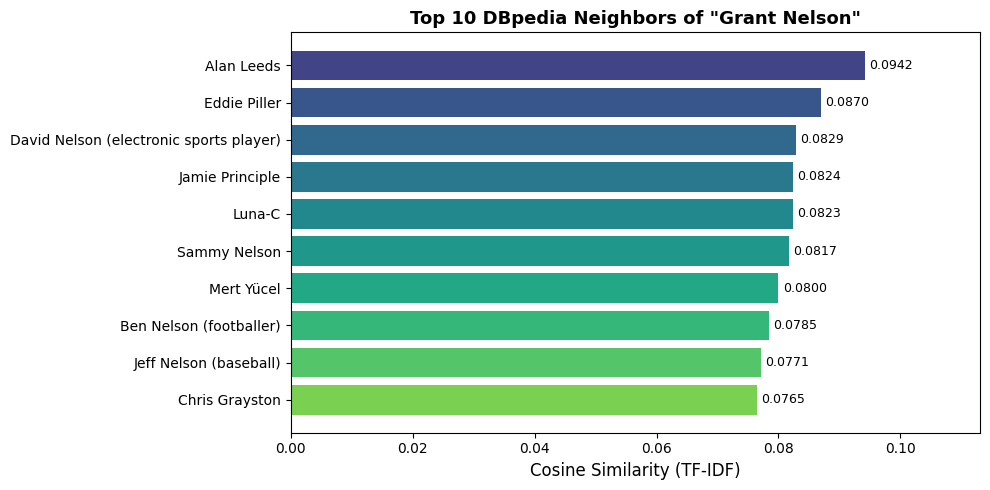

 Chart saved as 'part1_dbpedia_neighbors.png'


In [47]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis_r(np.linspace(0.2, 0.8, len(neighbors_df)))
bars = ax.barh(neighbors_df['name'][::-1], neighbors_df['dbpedia_similarity'][::-1], color=colors)
ax.set_xlabel('Cosine Similarity (TF-IDF)', fontsize=12)
ax.set_title(f'Top 10 DBpedia Neighbors of "{ref_name}"', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_xlim(0, neighbors_df['dbpedia_similarity'].max() * 1.2)
plt.tight_layout()
plt.savefig('part1_dbpedia_neighbors.png', dpi=150)
plt.show()
print(" Chart saved as 'part1_dbpedia_neighbors.png'")

---
## PART 2 – Wikipedia Pages: Full Text, Sentiment & Re-Ranking

### 2a. Helper – Fetch Wikipedia Full Text

In [48]:
wiki = wikipediaapi.Wikipedia(
    language='en',
    user_agent='DBpediaProject/1.0 (colab-student-project)'
)

def fetch_wikipedia_text(name):
    """
    Attempt to fetch full Wikipedia article text for a given name.
    Falls back to Wikipedia search API if direct lookup fails.
    Returns (title, full_text) or (name, '') if not found.
    """
    # Direct lookup
    page = wiki.page(name)
    if page.exists():
        return page.title, page.text

    # Try search API fallback
    try:
        url = "https://en.wikipedia.org/wiki/Grant_Nelson_(basketball)"
        params = {
            'action': 'query', 'list': 'search',
            'srsearch': name, 'srlimit': 1, 'format': 'json'
        }
        r = requests.get(url, params=params, timeout=10)
        results = r.json().get('query', {}).get('search', [])
        if results:
            title = results[0]['title']
            page = wiki.page(title)
            if page.exists():
                return page.title, page.text
    except Exception:
        pass

    return name, ''  # not found


### 2b. Print Full Wikipedia Article for the Reference Person

In [49]:
print(f" Fetching Wikipedia page for '{ref_name}'...\n")
ref_wiki_title, ref_wiki_text = fetch_wikipedia_text(ref_name)

if ref_wiki_text:
    print(f"{'='*70}")
    print(f"Wikipedia Article: {ref_wiki_title}")
    print(f"{'='*70}")
    print(ref_wiki_text)
    print(f"\n{'='*70}")
    print(f"Total characters: {len(ref_wiki_text):,} | Words: {len(ref_wiki_text.split()):,}")
else:
    print(f" No Wikipedia page found for '{ref_name}'. Will use DBpedia text as fallback.")
    ref_wiki_text = df.loc[ref_idx, 'text']

 Fetching Wikipedia page for 'Grant Nelson'...

Wikipedia Article: Grant Nelson
Grant Nelson may refer to:

Grant Nelson (basketball) (born 2002), American basketball player
Grant Nelson (DJ) (born 1971), British disc jockey and producer
Grant S. Nelson (born 1939), American professor

Total characters: 205 | Words: 30


### 2c. Sentiment Analysis of the Reference Person's Wikipedia Page

In [50]:
analyzer = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    """Run VADER sentence-level sentiment; return aggregate + per-sentence breakdown."""
    if not text:
        return {'compound': 0, 'pos': 0, 'neu': 0, 'neg': 0}, []

    sentences = re.split(r'(?<=[.!?])\s+', text)
    sentence_scores = []
    for sent in sentences:
        if len(sent.strip()) > 10:
            score = analyzer.polarity_scores(sent)
            sentence_scores.append({'sentence': sent[:120], **score})

    # Aggregate over all sentences
    if sentence_scores:
        agg = {
            'compound': np.mean([s['compound'] for s in sentence_scores]),
            'pos':      np.mean([s['pos']      for s in sentence_scores]),
            'neu':      np.mean([s['neu']      for s in sentence_scores]),
            'neg':      np.mean([s['neg']      for s in sentence_scores]),
        }
    else:
        agg = analyzer.polarity_scores(text)

    return agg, sentence_scores

ref_sentiment, ref_sent_scores = analyze_sentiment(ref_wiki_text)

# Display results
label = 'POSITIVE ' if ref_sentiment['compound'] >= 0.05 else \
        'NEGATIVE ' if ref_sentiment['compound'] <= -0.05 else 'NEUTRAL '

print(f"\n{'='*60}")
print(f"Sentiment Analysis: {ref_wiki_title}")
print(f"{'='*60}")
print(f"  Overall label  : {label}")
print(f"  Compound score : {ref_sentiment['compound']:+.4f}  (range: -1 to +1)")
print(f"  Positive       : {ref_sentiment['pos']:.4f}")
print(f"  Neutral        : {ref_sentiment['neu']:.4f}")
print(f"  Negative       : {ref_sentiment['neg']:.4f}")
print(f"  Sentences analyzed: {len(ref_sent_scores)}")


Sentiment Analysis: Grant Nelson
  Overall label  : POSITIVE 
  Compound score : +0.4201  (range: -1 to +1)
  Positive       : 0.1615
  Neutral        : 0.8385
  Negative       : 0.0000
  Sentences analyzed: 2


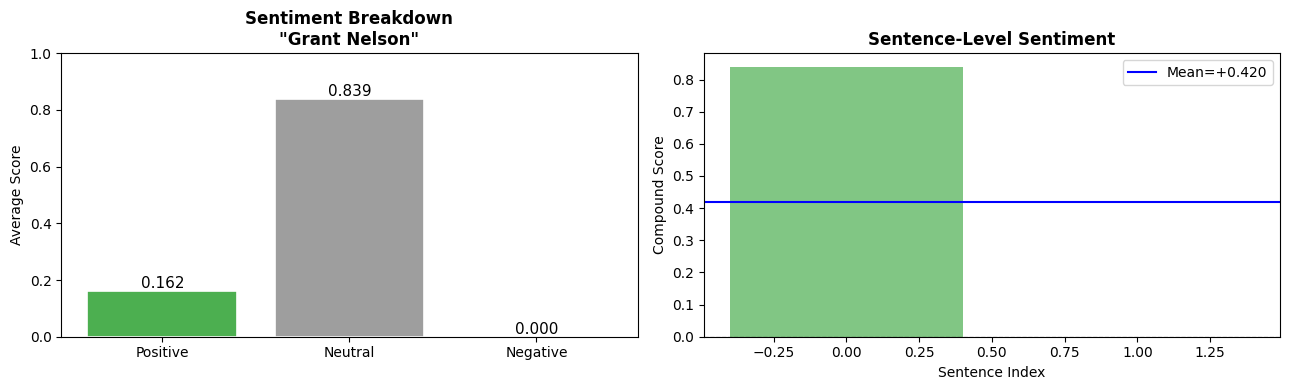

 Chart saved as 'part2_sentiment.png'


In [51]:
# Plot sentiment breakdown
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Bar chart: aggregate scores ---
cats = ['Positive', 'Neutral', 'Negative']
vals = [ref_sentiment['pos'], ref_sentiment['neu'], ref_sentiment['neg']]
bar_colors = ['#4CAF50', '#9E9E9E', '#F44336']
axes[0].bar(cats, vals, color=bar_colors, edgecolor='white', linewidth=1.2)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Average Score')
axes[0].set_title(f'Sentiment Breakdown\n"{ref_wiki_title}"', fontweight='bold')
for i, v in enumerate(vals):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)

# --- Compound score over sentences ---
compounds = [s['compound'] for s in ref_sent_scores]
x = range(len(compounds))
colors_line = ['#4CAF50' if c >= 0.05 else '#F44336' if c <= -0.05 else '#9E9E9E' for c in compounds]
axes[1].bar(x, compounds, color=colors_line, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axhline(ref_sentiment['compound'], color='blue', linewidth=1.5,
                linestyle='-', label=f"Mean={ref_sentiment['compound']:+.3f}")
axes[1].set_xlabel('Sentence Index')
axes[1].set_ylabel('Compound Score')
axes[1].set_title('Sentence-Level Sentiment', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('part2_sentiment.png', dpi=150)
plt.show()
print(" Chart saved as 'part2_sentiment.png'")

### 2d. Collect Wikipedia Text for All 10 Neighbors

In [52]:
wiki_data = []  # list of dicts

print(f" Fetching Wikipedia pages for 10 neighbors of '{ref_name}'...\n")

for _, row in neighbors_df.iterrows():
    name = row['name']
    db_rank = int(row['rank'])
    print(f"  [{db_rank:2d}/10] Fetching: {name}...", end=" ")
    title, text = fetch_wikipedia_text(name)
    sentiment, _ = analyze_sentiment(text) if text else ({'compound': 0, 'pos': 0, 'neu': 0, 'neg': 0}, [])
    wiki_data.append({
        'db_rank': db_rank,
        'name': name,
        'wiki_title': title,
        'wiki_text': text,
        'wiki_found': bool(text),
        'sentiment_compound': round(sentiment['compound'], 4),
        'sentiment_pos': round(sentiment['pos'], 4),
        'sentiment_neg': round(sentiment['neg'], 4),
        'wiki_word_count': len(text.split()) if text else 0
    })
    status = f" {len(text.split()):,} words" if text else " not found"
    print(status)

wiki_df = pd.DataFrame(wiki_data)
print(f"\n Wikipedia data collected for {wiki_df['wiki_found'].sum()}/10 neighbors.")
display(wiki_df[['db_rank','name','wiki_found','wiki_word_count','sentiment_compound']])

 Fetching Wikipedia pages for 10 neighbors of 'Grant Nelson'...

  [ 1/10] Fetching: Alan Leeds...  326 words
  [ 2/10] Fetching: Eddie Piller...  830 words
  [ 3/10] Fetching: David Nelson (electronic sports player)...  270 words
  [ 4/10] Fetching: Jamie Principle...  562 words
  [ 5/10] Fetching: Luna-C...  832 words
  [ 6/10] Fetching: Sammy Nelson...  531 words
  [ 7/10] Fetching: Mert Yücel...  177 words
  [ 8/10] Fetching: Ben Nelson (footballer)...  84 words
  [ 9/10] Fetching: Jeff Nelson (baseball)...  52 words
  [10/10] Fetching: Chris Grayston...  569 words

 Wikipedia data collected for 10/10 neighbors.


,db_rank,name,wiki_found,wiki_word_count,sentiment_compound
0,1,Alan Leeds,True,326,0.1461
1,2,Eddie Piller,True,830,0.2530
2,3,David Nelson (electronic sports player),True,270,0.2966
3,4,Jamie Principle,True,562,0.0781
4,5,Luna-C,True,832,0.2537
5,6,Sammy Nelson,True,531,0.2011
6,7,Mert Yücel,True,177,0.0390
7,8,Ben Nelson (footballer),True,84,0.0000
8,9,Jeff Nelson (baseball),True,52,-0.5267
9,10,Chris Grayston,True,569,0.2641


### 2e. Re-Rank Neighbors Using Wikipedia Page Similarity

In [53]:
# Build a small corpus: reference + neighbors (use DBpedia text as fallback)
corpus_texts = []
corpus_names = [ref_name]
corpus_texts.append(ref_wiki_text if ref_wiki_text else df.loc[ref_idx, 'text'])

for _, row in wiki_df.iterrows():
    corpus_names.append(row['name'])
    text = row['wiki_text'] if row['wiki_found'] else \
           df.loc[df['name'] == row['name'], 'text'].values[0] if row['name'] in df['name'].values else ''
    corpus_texts.append(text)

# TF-IDF on this small corpus
wiki_vectorizer = TfidfVectorizer(
    max_features=15000,
    stop_words='english',
    ngram_range=(1, 2)
)
try:
    wiki_tfidf = wiki_vectorizer.fit_transform(corpus_texts)
    ref_vec_wiki = wiki_tfidf[0]
    neighbor_vecs = wiki_tfidf[1:]
    wiki_sims = cosine_similarity(ref_vec_wiki, neighbor_vecs).flatten()
except Exception as e:
    print(f"TF-IDF error: {e}. Using zero similarities.")
    wiki_sims = np.zeros(len(wiki_df))

wiki_df['wiki_similarity'] = wiki_sims.round(4)
wiki_df = wiki_df.sort_values('wiki_similarity', ascending=False).reset_index(drop=True)
wiki_df['wiki_rank'] = wiki_df.index + 1

print("\n Wikipedia-based Re-Ranking:\n")
display(wiki_df[['wiki_rank', 'db_rank', 'name', 'wiki_similarity', 'sentiment_compound']]
        .sort_values('wiki_rank'))


 Wikipedia-based Re-Ranking:



,wiki_rank,db_rank,name,wiki_similarity,sentiment_compound
0,1,9,Jeff Nelson (baseball),0.1254,-0.5267
1,2,8,Ben Nelson (footballer),0.1249,0.0000
2,3,6,Sammy Nelson,0.0662,0.2011
3,4,3,David Nelson (electronic sports player),0.0575,0.2966
4,5,1,Alan Leeds,0.0145,0.1461
5,6,5,Luna-C,0.0108,0.2537
6,7,7,Mert Yücel,0.0099,0.0390
7,8,10,Chris Grayston,0.0093,0.2641
8,9,2,Eddie Piller,0.0083,0.2530
9,10,4,Jamie Principle,0.0067,0.0781


### 2f. Compare DBpedia Rank vs Wikipedia Rank

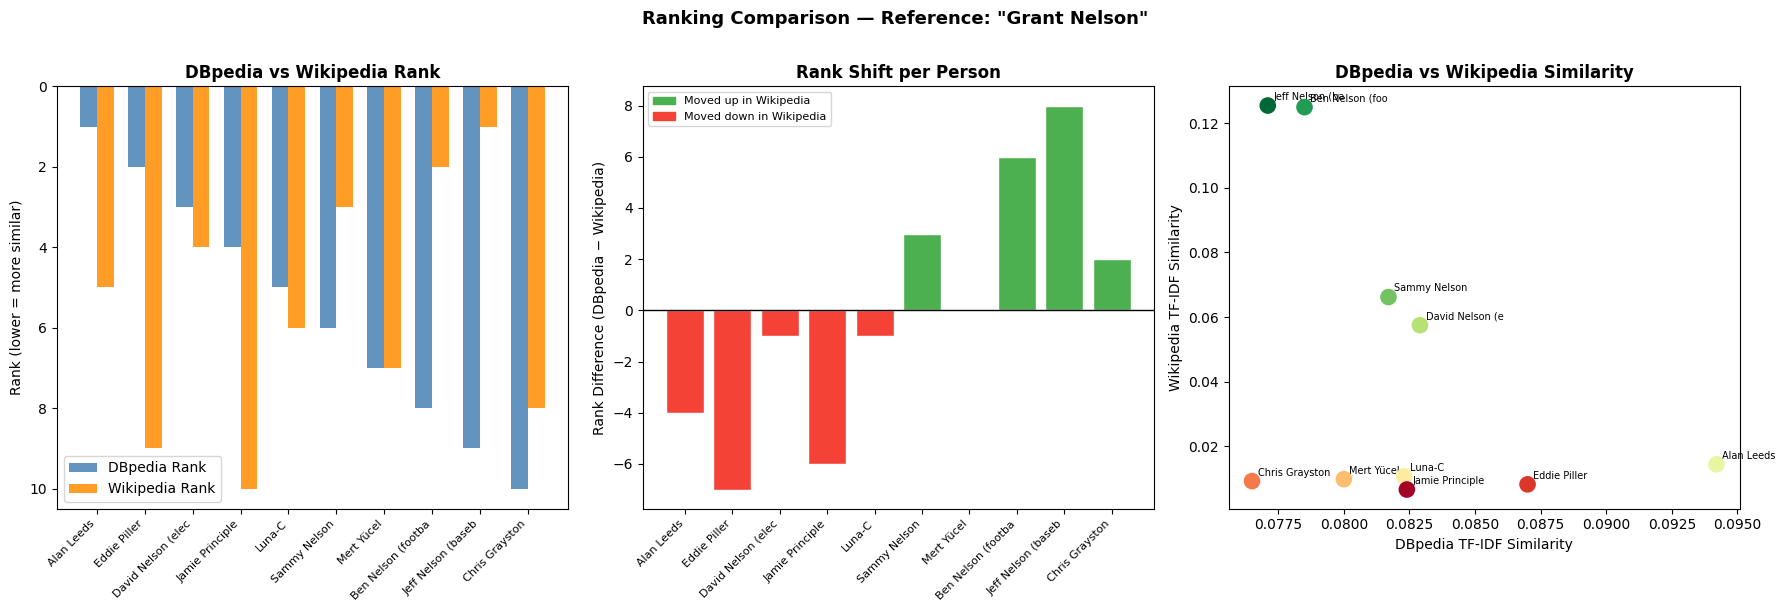

 Chart saved as 'part2_rank_comparison.png'


In [54]:
# Rank difference
wiki_df['rank_diff'] = wiki_df['db_rank'] - wiki_df['wiki_rank']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Plot 1: Side-by-side bars ──────────────────────────────────────────────
x = np.arange(len(wiki_df))
width = 0.35
plot_df = wiki_df.sort_values('db_rank')
axes[0].bar(x - width/2, plot_df['db_rank'],  width, label='DBpedia Rank',   color='steelblue',   alpha=0.85)
axes[0].bar(x + width/2, plot_df['wiki_rank'], width, label='Wikipedia Rank', color='darkorange', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([n[:18] for n in plot_df['name']], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Rank (lower = more similar)')
axes[0].set_title('DBpedia vs Wikipedia Rank', fontweight='bold')
axes[0].legend()
axes[0].invert_yaxis()

# ── Plot 2: Rank Difference ────────────────────────────────────────────────
diff_colors = ['#4CAF50' if d > 0 else '#F44336' if d < 0 else '#9E9E9E'
               for d in plot_df['rank_diff']]
axes[1].bar(x, plot_df['rank_diff'], color=diff_colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels([n[:18] for n in plot_df['name']], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Rank Difference (DBpedia − Wikipedia)')
axes[1].set_title('Rank Shift per Person', fontweight='bold')
green_patch = mpatches.Patch(color='#4CAF50', label='Moved up in Wikipedia')
red_patch   = mpatches.Patch(color='#F44336', label='Moved down in Wikipedia')
axes[1].legend(handles=[green_patch, red_patch], fontsize=8)

# ── Plot 3: Scatter DBpedia sim vs Wikipedia sim ───────────────────────────
scatter_df = wiki_df.merge(neighbors_df[['name','dbpedia_similarity']], on='name', how='left')
axes[2].scatter(scatter_df['dbpedia_similarity'], scatter_df['wiki_similarity'],
                c=scatter_df['wiki_rank'], cmap='RdYlGn_r', s=120, zorder=5)
for _, row in scatter_df.iterrows():
    axes[2].annotate(row['name'][:15],
                     (row['dbpedia_similarity'], row['wiki_similarity']),
                     fontsize=7, xytext=(4, 4), textcoords='offset points')
axes[2].set_xlabel('DBpedia TF-IDF Similarity')
axes[2].set_ylabel('Wikipedia TF-IDF Similarity')
axes[2].set_title('DBpedia vs Wikipedia Similarity', fontweight='bold')

plt.suptitle(f'Ranking Comparison — Reference: "{ref_name}"',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('part2_rank_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved as 'part2_rank_comparison.png'")

### 2g. Summary Table: Full Comparison

In [55]:
summary = wiki_df.sort_values('db_rank')[[
    'db_rank', 'wiki_rank', 'rank_diff', 'name',
    'wiki_word_count', 'wiki_similarity', 'sentiment_compound'
]].copy()

summary.columns = ['DBpedia Rank', 'Wiki Rank', 'Δ Rank',
                   'Name', 'Wiki Words', 'Wiki Similarity', 'Sentiment']

def color_diff(val):
    color = '#c8e6c9' if val > 0 else '#ffcdd2' if val < 0 else '#f5f5f5'
    return f'background-color: {color}'

styled = summary.style \
    .applymap(color_diff, subset=['Δ Rank']) \
    .format({'Wiki Similarity': '{:.4f}', 'Sentiment': '{:+.4f}', 'Wiki Words': '{:,}'}) \
    .set_caption(f'Ranking Comparison for neighbors of "{ref_name}"')

display(styled)

/tmp/ipykernel_26682/534614795.py:14: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_diff, subset=['Δ Rank']) \


,DBpedia Rank,Wiki Rank,Δ Rank,Name,Wiki Words,Wiki Similarity,Sentiment
4,1,5,-4,Alan Leeds,326,0.0145,+0.1461
8,2,9,-7,Eddie Piller,830,0.0083,+0.2530
3,3,4,-1,David Nelson (electronic sports player),270,0.0575,+0.2966
9,4,10,-6,Jamie Principle,562,0.0067,+0.0781
5,5,6,-1,Luna-C,832,0.0108,+0.2537
2,6,3,3,Sammy Nelson,531,0.0662,+0.2011
6,7,7,0,Mert Yücel,177,0.0099,+0.0390
1,8,2,6,Ben Nelson (footballer),84,0.1249,+0.0000
0,9,1,8,Jeff Nelson (baseball),52,0.1254,-0.5267
7,10,8,2,Chris Grayston,569,0.0093,+0.2641


---
## PART 3 – Interactive Widget: Find 10 Closest People

### 3a. Pre-compute Full TF-IDF (needed for interactive lookup)

In [56]:
# This cell re-confirms the TF-IDF matrix is ready (already built in Part 1)
print(f" TF-IDF matrix ready: {tfidf_matrix.shape[0]:,} people × {tfidf_matrix.shape[1]:,} features")
print("   The interactive widget below uses this matrix for instant lookup.")

 TF-IDF matrix ready: 42,786 people × 817,885 features
   The interactive widget below uses this matrix for instant lookup.


### 3b. Interactive Search Widget

In [ ]:
# ═══════════════════════════════════════════════════════════
# PART 3 – Interactive Notebook Widget
# ═══════════════════════════════════════════════════════════

# --- UI Components ---
style = {'description_width': 'initial'}
# Clean data
df['name'] = df['name'].astype(str).str.strip()

name_input = widgets.Combobox(
    placeholder='Type a name (e.g. Sophie Crumb)',
    options=sorted(df['name'].tolist()),
    description=' Person:',
    style=style,
    layout=widgets.Layout(width='420px')
)

top_n_slider = widgets.IntSlider(
    value=10, min=3, max=20, step=1,
    description='Top N neighbors:',
    style=style,
    layout=widgets.Layout(width='380px')
)

show_wiki = widgets.Checkbox(
    value=False,
    description='Fetch & show Wikipedia similarity (slower)',
    style=style
)

search_btn = widgets.Button(
    description='Find Neighbors',
    button_style='primary',
    icon='search',
    layout=widgets.Layout(width='160px', height='36px')
)

output_area = widgets.Output()

# --- Search Logic ---
def on_search(btn):
    with output_area:
        clear_output(wait=True)
        query = name_input.value.strip()
        if not query:
            print(" Please enter a name.")
            return

        # Find person
        mask = df['name'].str.lower().str.contains(query.lower(), na=False)
        matches = df[mask]
        if matches.empty:
            print(f" '{query}' not found in the DBpedia dataset.")
            print("\n Try partial names, e.g. 'Crumb' instead of 'Sophie Crumb'.")
            # Show close suggestions
            suggestions = df[df['name'].str.lower().str.contains(
                query.lower().split()[0], na=False)]['name'].head(5).tolist()
            if suggestions:
                print(f"\nDid you mean one of these?")
                for s in suggestions:
                    print(f"  • {s}")
            return

        person_idx = matches.index[0]
        person_name = df.loc[person_idx, 'name']
        top_n = top_n_slider.value

        print(f"\n{'='*65}")
        print(f"    {person_name}")
        print(f"{'='*65}")
        print(f"DBpedia text: {df.loc[person_idx, 'text'][:300]}...\n")

        # Nearest neighbors
        result = get_top_neighbors(person_idx, tfidf_matrix, df, top_n=top_n)

        print(f"\n Top {top_n} DBpedia Neighbors (TF-IDF Cosine Similarity):\n")
        display(result[['rank','name','dbpedia_similarity']]
                .style.background_gradient(subset=['dbpedia_similarity'], cmap='Blues')
                .format({'dbpedia_similarity': '{:.4f}'})
                .set_caption(f"Neighbors of '{person_name}'"))

        # --- Plot ---
        fig, ax = plt.subplots(figsize=(10, max(4, top_n * 0.45)))
        cmap = plt.cm.Blues(np.linspace(0.4, 0.9, len(result)))
        bars = ax.barh(result['name'][::-1], result['dbpedia_similarity'][::-1], color=cmap)
        ax.set_xlabel('Cosine Similarity (TF-IDF)', fontsize=11)
        ax.set_title(f'Top {top_n} Nearest Neighbors of "{person_name}"',
                     fontsize=12, fontweight='bold')
        ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
        ax.set_xlim(0, result['dbpedia_similarity'].max() * 1.25)
        plt.tight_layout()
        plt.show()

        # Optional Wikipedia re-ranking
        if show_wiki.value:
            print("\n⏳ Fetching Wikipedia pages for re-ranking (this takes ~30s)...")
            corpus = [df.loc[person_idx, 'text']]
            for _, row in result.iterrows():
                _, wtext = fetch_wikipedia_text(row['name'])
                corpus.append(wtext if wtext else df.loc[row['index'], 'text'])
                print(f"    {row['name'][:40]}")

            try:
                wv = TfidfVectorizer(stop_words='english')
                wmat = wv.fit_transform(corpus)
                wsims = cosine_similarity(wmat[0], wmat[1:]).flatten()
                result['wiki_similarity'] = wsims.round(4)
                result['wiki_rank'] = result['wiki_similarity'].rank(ascending=False).astype(int)
                result['rank_diff'] = result['rank'] - result['wiki_rank']

                print("\n DBpedia vs Wikipedia Ranking:\n")
                display(result[['rank','wiki_rank','rank_diff','name',
                                 'dbpedia_similarity','wiki_similarity']]
                        .style.format({'dbpedia_similarity': '{:.4f}',
                                       'wiki_similarity': '{:.4f}'})
                        .applymap(lambda v: 'color: green' if v > 0 else
                                  'color: red' if v < 0 else '',
                                  subset=['rank_diff']))
            except Exception as e:
                print(f" Wikipedia re-ranking failed: {e}")

search_btn.on_click(on_search)

# --- Layout ---
header = widgets.HTML(
    "<h3 style='color:#1565C0; font-family:sans-serif; margin-bottom:6px;'>"
    " DBpedia People Similarity Explorer</h3>"
    "<p style='font-family:sans-serif; color:#555; margin-top:0;'>"
    "Enter any name from the DBpedia dataset to find the 10 most similar people.</p>"
)

ui = widgets.VBox([
    header,
    widgets.HBox([name_input, top_n_slider]),
    widgets.HBox([show_wiki, search_btn]),
    output_area
], layout=widgets.Layout(
    border='2px solid #1565C0',
    padding='16px',
    border_radius='8px'
))

display(ui)

---
## 📋 Quick Demo: Run for any Suggested Name

Use this cell for the live in-class demonstration — just change `DEMO_NAME`.


    Jonathan Hoefler

DBpedia text:
jonathan hoefler born august 22 1970 is an american typeface designer hoefler pronounced heffler founded the hoefler type foundry in 1989 a type foundry in new york in 1999 hoefler began working with type designer tobias frerejones and from 20052014 the company operated under the name hoefler frerejones until their public splithoefler has designed original typefaces for rolling stone magazine harp



,rank,name,dbpedia_similarity
0,1,Tobias Frere-Jones,0.3904
1,2,Jean François Porchez,0.1923
2,3,Albert-Jan Pool,0.1386
3,4,Theo Rehak,0.1319
4,5,Rudy VanderLans,0.0957
5,6,True (artist),0.0921
6,7,Mike Kohnke,0.0916
7,8,Gerry Gersten,0.0912
8,9,Anita Kunz,0.0903
9,10,Darcy Frey,0.0870


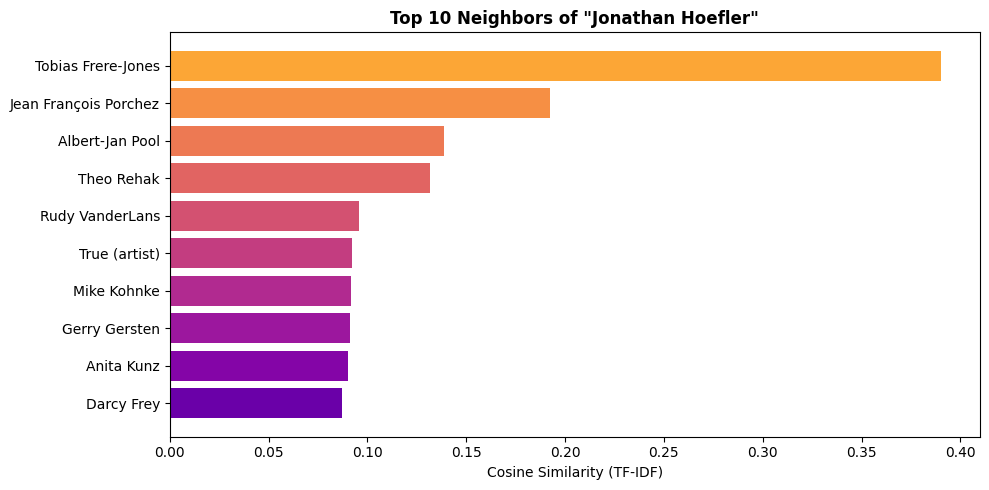

In [58]:
# ─── CHANGE THIS NAME during the live demo ────────────────────────────────────
DEMO_NAME = "Jonathan Hoefler"   # ← replace with any suggested name
DEMO_TOP_N = 10
# ──────────────────────────────────────────────────────────────────────────────

mask = df['name'].str.lower().str.contains(DEMO_NAME.lower(), na=False)
matches = df[mask]

if matches.empty:
    print(f" '{DEMO_NAME}' not found. Available close matches:")
    print(df[df['name'].str.lower().str.contains(
        DEMO_NAME.lower().split()[0], na=False)]['name'].head(10).tolist())
else:
    demo_idx = matches.index[0]
    demo_name = df.loc[demo_idx, 'name']
    demo_result = get_top_neighbors(demo_idx, tfidf_matrix, df, top_n=DEMO_TOP_N)

    print(f"\n{'='*60}")
    print(f"    {demo_name}")
    print(f"{'='*60}")
    print(f"\nDBpedia text:\n{df.loc[demo_idx, 'text'][:400]}\n")

    display(demo_result[['rank','name','dbpedia_similarity']])

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.plasma(np.linspace(0.2, 0.8, DEMO_TOP_N))
    ax.barh(demo_result['name'][::-1], demo_result['dbpedia_similarity'][::-1], color=colors)
    ax.set_xlabel('Cosine Similarity (TF-IDF)')
    ax.set_title(f'Top {DEMO_TOP_N} Neighbors of "{demo_name}"', fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 📦 Download All Output Charts

In [59]:
from google.colab import files
import os

charts = ['part1_dbpedia_neighbors.png', 'part2_sentiment.png', 'part2_rank_comparison.png']
for chart in charts:
    if os.path.exists(chart):
        files.download(chart)
        print(f"  Downloaded: {chart}")
    else:
        print(f" Not found (may not have been generated yet): {chart}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: part1_dbpedia_neighbors.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: part2_sentiment.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: part2_rank_comparison.png
